# GT Sigma Distribution
Inspect the distribution of sigma values from the ground-truth Gaussian parameters to pick a good `bg_sigma_threshold`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid", palette="muted")
%matplotlib inline

In [2]:
PATH = "/ste/rnd/User/vice_vi/Dataset/clean_dataset/params/params_sig_k5/parameters_sig_k5.npy"

params = np.load(PATH, mmap_mode="r")
print(f"Shape  : {params.shape}")
print(f"Dtype  : {params.dtype}")
print(f"Sample : {params.flat[:6]}")

# Layout is (C, H, W) where C = n_gaussians * 3  (a, mu, sigma per gaussian)
# Sigma channels are at indices 2, 5, 8, ...
n_channels  = params.shape[0]
n_gaussians = n_channels // 3
sigma_idx   = [3 * k + 2 for k in range(n_gaussians)]
print(f"\nn_gaussians : {n_gaussians}")
print(f"Sigma channels : {sigma_idx}")

Shape  : (15, 15000, 3500)
Dtype  : float32
Sample : [0.07066043 0.06710903 0.07425232 0.07697561 0.07641011 0.08407217]

n_gaussians : 5
Sigma channels : [2, 5, 8, 11, 14]


In [3]:
# ── Two views: ALL pixels (what the normalizer sees) vs active only ──────────
amp_idx = [3 * k for k in range(n_gaussians)]

all_sigmas_all    = []   # no amp filter — matches StatsComputer
all_sigmas_active = []   # amp > 1e-3   — matches loss masking

for k in range(n_gaussians):
    amp   = params[amp_idx[k]].reshape(-1)
    sigma = params[sigma_idx[k]].reshape(-1)
    finite = np.isfinite(sigma)
    all_sigmas_all.append(sigma[finite])
    all_sigmas_active.append(sigma[finite & (amp > 1e-3)])

sigmas_all    = np.concatenate(all_sigmas_all)
sigmas_active = np.concatenate(all_sigmas_active)
# use active as default for downstream cells
sigmas = sigmas_active

def _stats(arr, label):
    print(f"\n── {label} ({len(arr):,} samples) ──")
    for name, val in [
        ("mean",   arr.mean()),
        ("std",    arr.std()),
        ("min",    arr.min()),
        ("p25",    np.percentile(arr, 25)),
        ("median", np.median(arr)),
        ("p75",    np.percentile(arr, 75)),
        ("p90",    np.percentile(arr, 90)),
        ("p95",    np.percentile(arr, 95)),
        ("p99",    np.percentile(arr, 99)),
        ("max",    arr.max()),
    ]:
        print(f"  {name:<8}: {val:.4f}")

_stats(sigmas_all,    "ALL pixels  (matches StatsComputer / normalization logs)")
_stats(sigmas_active, "Active only (amp > 1e-3, matches loss masking)")


── ALL pixels  (matches StatsComputer / normalization logs) (262,500,000 samples) ──
  mean    : 0.8384
  std     : 1.6740
  min     : 0.0000
  p25     : 0.0000
  median  : 0.0000
  p75     : 1.1050
  p90     : 2.7189
  p95     : 3.9707
  p99     : 7.0238
  max     : 50.0000

── Active only (amp > 1e-3, matches loss masking) (102,732,018 samples) ──
  mean    : 2.1393
  std     : 2.0873
  min     : 0.6711
  p25     : 0.7993
  median  : 1.4416
  p75     : 2.7583
  p90     : 4.4077
  p95     : 5.6774
  p99     : 9.3063
  max     : 50.0000


/tmp/ipykernel_312391/563181241.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/vice_vi/.conda/envs/dlr-cu12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


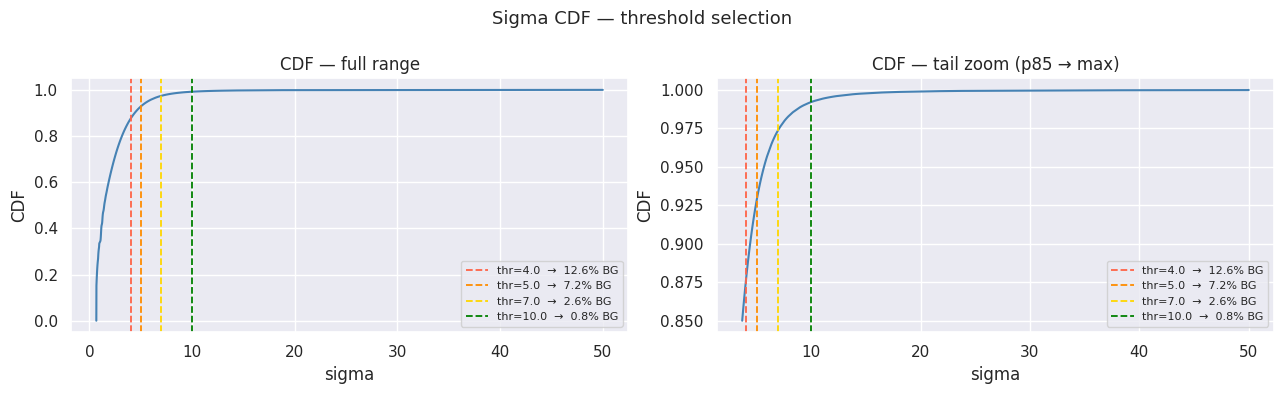

 threshold   % suppressed    # suppressed   flatness at half-window
       3.0         21.92%      22,515,394                     0.0%
       4.0         12.56%      12,904,333                     0.0%
       5.0          7.20%       7,395,033                     0.0%
       6.0          4.22%       4,340,399                     0.0%
       7.0          2.58%       2,649,938                     0.0%
      10.0          0.79%         810,097                     0.0%
      15.0          0.22%         228,468                     0.4%


In [4]:
# CDF — shows exactly what % of pixels each threshold suppresses
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full CDF
ax = axes[0]
sorted_s = np.sort(sigmas)
cdf      = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
ax.plot(sorted_s, cdf, color="steelblue", lw=1.5)
for thr, col in zip([4.0, 5.0, 7.0, 10.0], ["tomato", "darkorange", "gold", "green"]):
    pct_above = 100.0 * (sigmas > thr).mean()
    ax.axvline(thr, color=col, lw=1.3, linestyle="--", label=f"thr={thr}  →  {pct_above:.1f}% BG")
ax.set_xlabel("sigma")
ax.set_ylabel("CDF")
ax.set_title("CDF — full range")
ax.legend(fontsize=8)

# Right: zoom into the tail (p85 to max) where the threshold decision matters
ax2   = axes[1]
p85   = float(np.percentile(sigmas, 85))
tail  = sorted_s[sorted_s >= p85]
tail_cdf = np.linspace(0.85, 1.0, len(tail))
ax2.plot(tail, tail_cdf, color="steelblue", lw=1.5)
for thr, col in zip([4.0, 5.0, 7.0, 10.0], ["tomato", "darkorange", "gold", "green"]):
    pct_above = 100.0 * (sigmas > thr).mean()
    ax2.axvline(thr, color=col, lw=1.3, linestyle="--", label=f"thr={thr}  →  {pct_above:.1f}% BG")
ax2.set_xlabel("sigma")
ax2.set_ylabel("CDF")
ax2.set_title("CDF — tail zoom (p85 → max)")
ax2.legend(fontsize=8)

fig.suptitle("Sigma CDF — threshold selection", fontsize=13)
fig.tight_layout()
plt.show()

# Print a clean suppression table
print(f"{'threshold':>10}  {'% suppressed':>13}  {'# suppressed':>14}  {'flatness at half-window':>24}")
half_window = 50
for thr in [3.0, 4.0, 5.0, 6.0, 7.0, 10.0, 15.0]:
    pct  = 100.0 * (sigmas > thr).mean()
    n    = int((sigmas > thr).sum())
    flat = np.exp(-half_window**2 / (2 * thr**2))
    print(f"{thr:>10.1f}  {pct:>12.2f}%  {n:>14,}  {flat:>23.1%}")

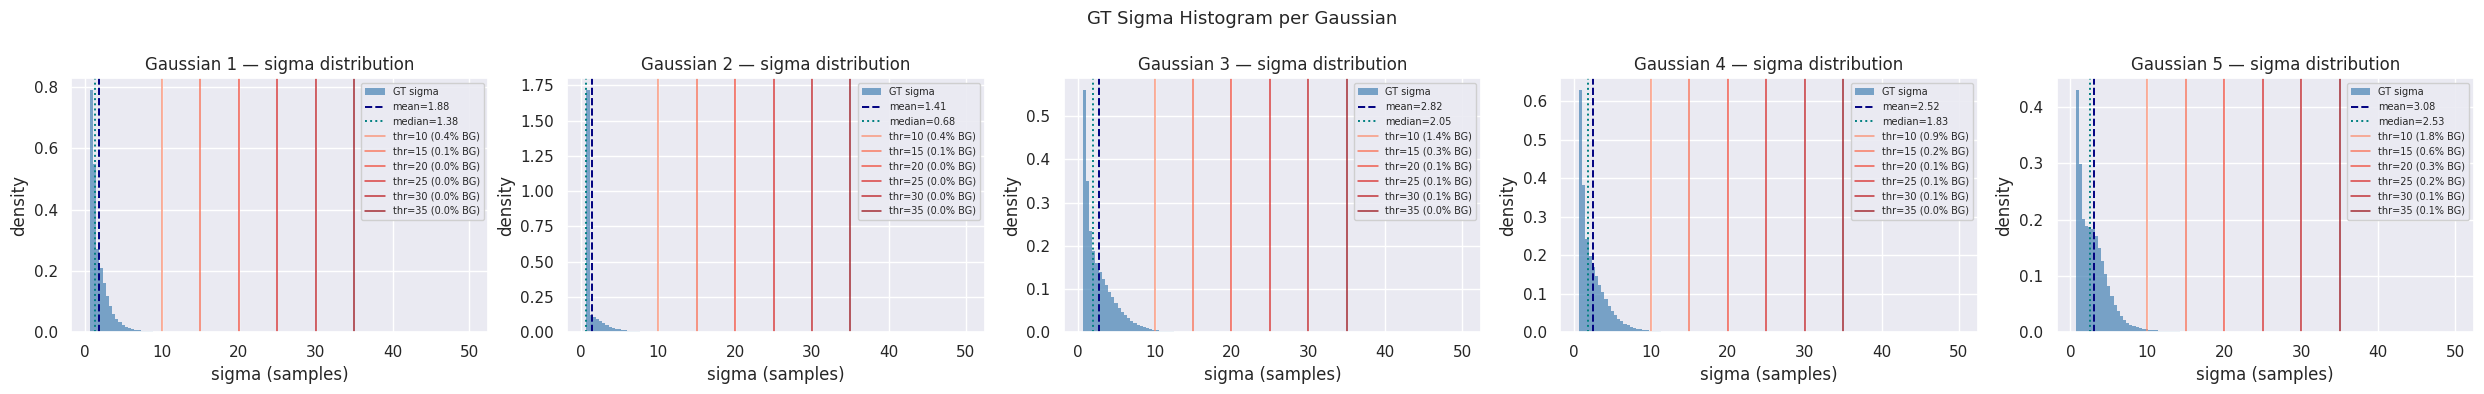

In [5]:
fig, axes = plt.subplots(1, n_gaussians, figsize=(5 * n_gaussians, 4), sharey=False)
if n_gaussians == 1:
    axes = [axes]

candidate_thresholds = [10, 15, 20, 25, 30, 35]
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(candidate_thresholds)))

for k, ax in enumerate(axes):
    amp   = params[amp_idx[k]].reshape(-1)
    sigma = params[sigma_idx[k]].reshape(-1)
    s     = sigma[amp > 1e-3]
    s     = s[np.isfinite(s)]

    ax.hist(s, bins=120, density=True, color="steelblue", alpha=0.7, edgecolor="none", label="GT sigma")
    ax.axvline(s.mean(),   color="navy",   lw=1.4, linestyle="--", label=f"mean={s.mean():.2f}")
    ax.axvline(np.median(s), color="teal", lw=1.4, linestyle=":",  label=f"median={np.median(s):.2f}")

    for thr, col in zip(candidate_thresholds, colors):
        pct = 100.0 * (s > thr).mean()
        ax.axvline(thr, color=col, lw=1.1, alpha=0.85, label=f"thr={thr} ({pct:.1f}% BG)")

    ax.set_title(f"Gaussian {k+1} — sigma distribution")
    ax.set_xlabel("sigma (samples)")
    ax.set_ylabel("density")
    ax.legend(fontsize=7, framealpha=0.9)

fig.suptitle("GT Sigma Histogram per Gaussian", fontsize=13)
fig.tight_layout()
plt.show()

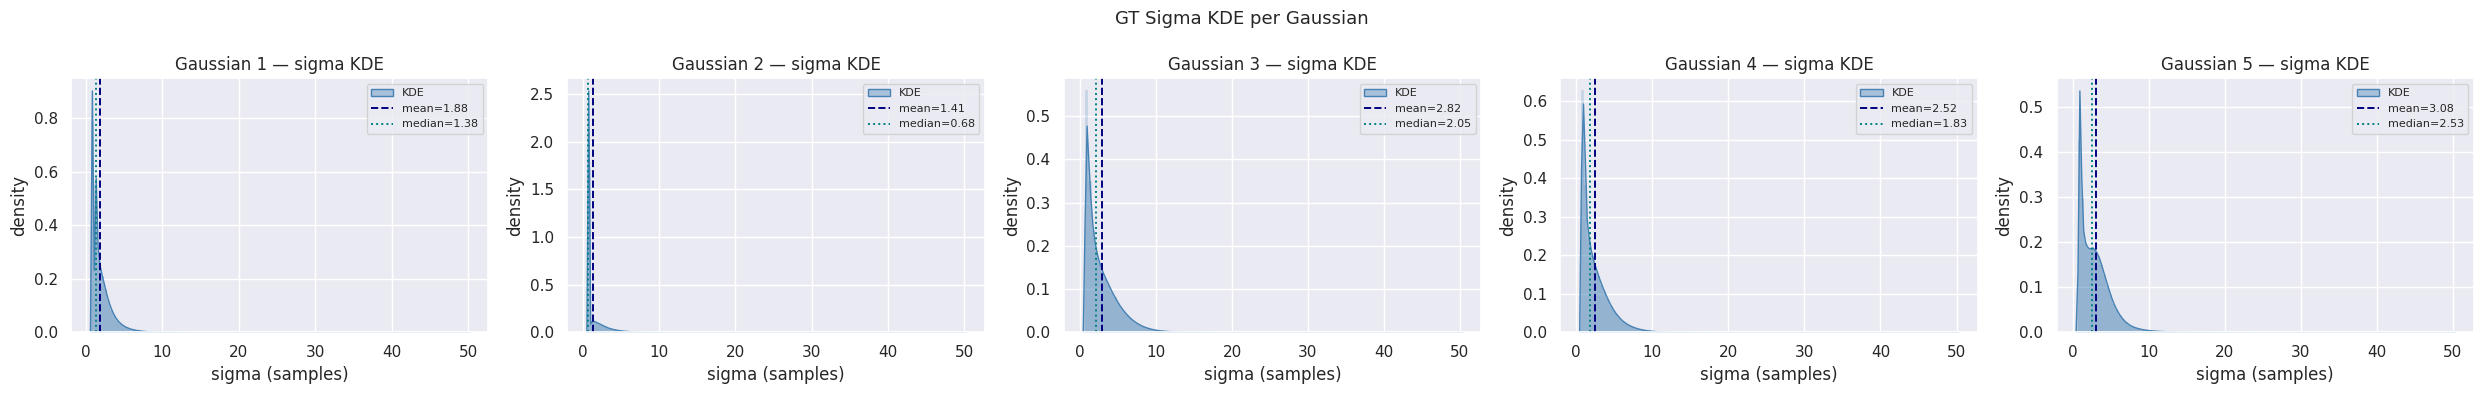

In [6]:
fig, axes = plt.subplots(1, n_gaussians, figsize=(5 * n_gaussians, 4), sharey=False)
if n_gaussians == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    amp   = params[amp_idx[k]].reshape(-1)
    sigma = params[sigma_idx[k]].reshape(-1)
    s     = sigma[amp > 1e-3]
    s     = s[np.isfinite(s)]

    sns.kdeplot(s, ax=ax, fill=True, color="steelblue", alpha=0.4, label="KDE")
    ax.hist(s, bins=120, density=True, color="steelblue", alpha=0.2, edgecolor="none")
    ax.axvline(s.mean(),     color="navy", lw=1.4, linestyle="--", label=f"mean={s.mean():.2f}")
    ax.axvline(np.median(s), color="teal", lw=1.4, linestyle=":",  label=f"median={np.median(s):.2f}")
    ax.set_title(f"Gaussian {k+1} — sigma KDE")
    ax.set_xlabel("sigma (samples)")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

fig.suptitle("GT Sigma KDE per Gaussian", fontsize=13)
fig.tight_layout()
plt.show()

=== Outlier analysis (IQR method) ===


  g1: Q1=0.83  Q3=2.33  IQR=1.50  fences=[-1.42, 4.57]  outliers=2,636,248 (5.28%)
  g2: Q1=0.67  Q3=1.46  IQR=0.79  fences=[-0.51, 2.64]  outliers=2,394,552 (13.54%)
  g3: Q1=1.13  Q3=3.79  IQR=2.66  fences=[-2.86, 7.79]  outliers=218,466 (3.82%)
  g4: Q1=1.05  Q3=3.32  IQR=2.27  fences=[-2.35, 6.72]  outliers=409,642 (4.22%)
  g5: Q1=1.27  Q3=4.01  IQR=2.74  fences=[-2.84, 8.12]  outliers=633,616 (3.22%)


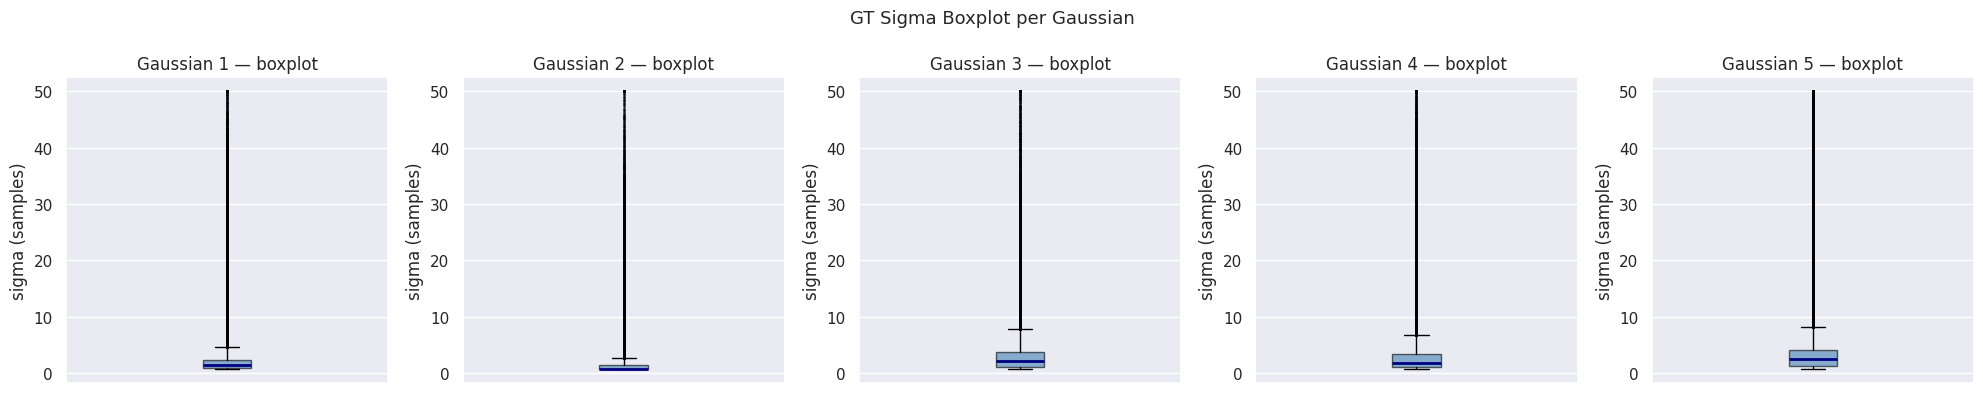

In [7]:
fig, axes = plt.subplots(1, n_gaussians, figsize=(4 * n_gaussians, 4), sharey=False)
if n_gaussians == 1:
    axes = [axes]

print("=== Outlier analysis (IQR method) ===")
for k, ax in enumerate(axes):
    amp   = params[amp_idx[k]].reshape(-1)
    sigma = params[sigma_idx[k]].reshape(-1)
    s     = sigma[amp > 1e-3]
    s     = s[np.isfinite(s)]

    q1, q3   = np.percentile(s, [25, 75])
    iqr      = q3 - q1
    lo_fence = q1 - 1.5 * iqr
    hi_fence = q3 + 1.5 * iqr
    outliers = s[(s < lo_fence) | (s > hi_fence)]

    print(f"  g{k+1}: Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}  "
          f"fences=[{lo_fence:.2f}, {hi_fence:.2f}]  "
          f"outliers={len(outliers):,} ({100*len(outliers)/len(s):.2f}%)")

    ax.boxplot(s, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               medianprops=dict(color="navy", linewidth=2),
               flierprops=dict(marker=".", markersize=1, alpha=0.2, color="tomato"))
    ax.set_title(f"Gaussian {k+1} — boxplot")
    ax.set_ylabel("sigma (samples)")
    ax.set_xticks([])

fig.suptitle("GT Sigma Boxplot per Gaussian", fontsize=13)
fig.tight_layout()
plt.show()

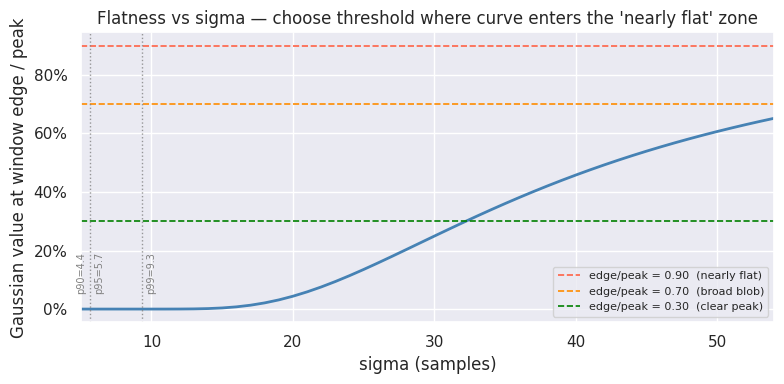


Suggested bg_sigma_threshold range based on your data:
  edge/peak >= 70%  →  sigma >= 59.2  [broad blob  (aggressive)]
  edge/peak >= 80%  →  sigma >= 74.8  [moderate]
  edge/peak >= 90%  →  sigma >= 108.9  [nearly flat (conservative)]


In [8]:
# How "flat" does a Gaussian look at the window edges for a given sigma?
# Window half-width = 50 samples (range -20 to 80, center at 30)
half_window = 50
thresholds  = np.arange(5, 55, 1)
edge_ratio  = np.exp(-half_window**2 / (2 * thresholds**2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, edge_ratio, color="steelblue", lw=2)
ax.axhline(0.9, color="tomato",   lw=1.2, linestyle="--", label="edge/peak = 0.90  (nearly flat)")
ax.axhline(0.7, color="darkorange", lw=1.2, linestyle="--", label="edge/peak = 0.70  (broad blob)")
ax.axhline(0.3, color="green",    lw=1.2, linestyle="--", label="edge/peak = 0.30  (clear peak)")

# Mark p90, p95, p99 of all sigmas on the x-axis
for q, label in [(90, "p90"), (95, "p95"), (99, "p99")]:
    v = np.percentile(sigmas, q)
    ax.axvline(v, color="grey", lw=1.0, linestyle=":", alpha=0.8)
    ax.text(v + 0.3, 0.05, f"{label}={v:.1f}", fontsize=7, color="grey", rotation=90, va="bottom")

ax.set_xlabel("sigma (samples)")
ax.set_ylabel("Gaussian value at window edge / peak")
ax.set_title("Flatness vs sigma — choose threshold where curve enters the 'nearly flat' zone")
ax.legend(fontsize=8)
ax.set_xlim(thresholds[0], thresholds[-1])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
fig.tight_layout()
plt.show()

print("\nSuggested bg_sigma_threshold range based on your data:")
for ratio, label in [(0.7, "broad blob  (aggressive)"), (0.8, "moderate"), (0.9, "nearly flat (conservative)")]:
    thr = np.sqrt(-half_window**2 / (2 * np.log(ratio)))
    print(f"  edge/peak >= {ratio:.0%}  →  sigma >= {thr:.1f}  [{label}]")